# Day 17 - GRU & Seq2Seq - 门控循环单元与编码器-解码器

> 目标: 理解 GRU 如何用两个门简化 LSTM, 以及 Seq2Seq 的编码器-解码器架构
>
> 核心: GRU = 更新门 + 重置门 (LSTM 的 3 个门 -> 2 个门)

---

## RNN vs LSTM vs GRU

```
RNN:   h_t = tanh(W * [x_t, h_{t-1}])                       1 组权重
LSTM:  i, f, o, g  四个变换, 细胞状态 C_t                   4 组权重
GRU:   z (更新门) + r (重置门), 没有细胞状态                  3 组权重

精度:   LSTM >= GRU >> RNN   (大数据集 LSTM 略好, 小数据集 GRU 性价比高)
速度:   GRU > LSTM (少一组门, 计算更快)
参数:   GRU 是 LSTM 的 3/4
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 17 - GRU & Seq2Seq')
print('=' * 40)

Day 17 - GRU & Seq2Seq


## 1. GRU 的两个门

> GRU (Cho et al., 2014) 把 LSTM 的遗忘门 + 输入门合并成更新门, 去掉输出门, 加入重置门

### 重置门 (Reset Gate) - 决定忘记多少过去

```
r_t = sigmoid(W_r * [h_{t-1}, x_t] + b_r)

作用: 控制前一个隐藏状态 h_{t-1} 有多少被"重置"
  r_t ≈ 0: 忽略过去, 从当前输入重新开始 (短依赖)
  r_t ≈ 1: 保留过去全部信息 (长依赖)
```

### 更新门 (Update Gate) - 决定保留多少旧信息 + 加入多少新信息

```
z_t = sigmoid(W_z * [h_{t-1}, x_t] + b_z)

作用: LSTM 遗忘门 + 输入门的合并
  z_t ≈ 0: 完全用新信息替换旧信息
  z_t ≈ 1: 完全保留旧信息, 忽略当前输入
```

### GRU 完整公式

```
r_t = sigmoid(W_r * [h_{t-1}, x_t])         # 重置门
z_t = sigmoid(W_z * [h_{t-1}, x_t])         # 更新门
n_t = tanh(W_n * [r_t * h_{t-1}, x_t])      # 候选隐藏状态 (使用重置后的过去)
h_t = (1 - z_t) * n_t + z_t * h_{t-1}       # 最终隐藏状态 (更新门平衡新旧)
                                           # ← 跟 LSTM 一样是加法路径!
```

### LSTM vs GRU 对应关系

```
LSTM:   遗忘门 f  + 输入门 i  = GRU 更新门 z
        输出门 o              = GRU 去掉 (h_t 直接等于 C_t 的某种形式)
        重置门                = GRU 新增 (控制过去对候选的贡献)
```

In [2]:
# ============================================
# 手写 GRU 前向传播
# ============================================

def gru_step(x_t, h_prev, W_x, W_h, b):
    """
    单步 GRU 前向
    W_x: (3*hidden_size, input_size)   ← x 的权重 (r, z, n)
    W_h: (3*hidden_size, hidden_size)  ← h 的权重
    """
    hs = h_prev.shape[0]

    gates_x = x_t @ W_x.T + b  # (3*hs,)
    gates_h = h_prev @ W_h.T   # (3*hs,)

    # 拆成 3 份: r, z, n
    r = torch.sigmoid(gates_x[:hs] + gates_h[:hs])          # 重置门
    z = torch.sigmoid(gates_x[hs:2*hs] + gates_h[hs:2*hs])  # 更新门

    # n: 候选隐藏状态 (用重置门处理后的 h_prev)
    n = torch.tanh(gates_x[2*hs:] + r * gates_h[2*hs:])

    # 最终隐藏状态: 更新门平衡新旧
    h_next = (1 - z) * n + z * h_prev

    return h_next, (r, z, n)


def gru_unfold(inputs, h0, W_x, W_h, b):
    """沿时间步展开 GRU"""
    seq_len = inputs.shape[0]
    hidden_size = h0.shape[0]
    hiddens = torch.zeros(seq_len, hidden_size)
    h_t = h0
    for t in range(seq_len):
        h_t, _ = gru_step(inputs[t], h_t, W_x, W_h, b)
        hiddens[t] = h_t
    return hiddens


# 测试手写 GRU
torch.manual_seed(42)
input_size, hidden_size, seq_len = 4, 8, 5

W_x = torch.randn(3 * hidden_size, input_size) * 0.1
W_h = torch.randn(3 * hidden_size, hidden_size) * 0.1
b = torch.zeros(3 * hidden_size)
h0 = torch.zeros(hidden_size)
inputs = torch.randn(seq_len, input_size)

hiddens = gru_unfold(inputs, h0, W_x, W_h, b)
print(f'输入形状: {tuple(inputs.shape)}')
print(f'隐藏状态形状: {tuple(hiddens.shape)}')
print(f'最后时间步 h[:8]: {hiddens[-1, :8].detach().numpy().round(4)}')

输入形状: (5, 4)
隐藏状态形状: (5, 8)
最后时间步 h[:8]: [-0.1866 -0.0563 -0.0282  0.0764  0.1482 -0.024  -0.0024 -0.1103]


## 2. PyTorch nn.GRU 使用

> API 跟 nn.RNN/nn.LSTM 完全一致

```python
nn.GRU(input_size, hidden_size, num_layers, batch_first, dropout, bidirectional)

输出: (output, hn)
  output: (batch, seq_len, hidden_size * num_directions)
  hn:     (num_layers * num_directions, batch, hidden_size)

GRU 没有细胞状态! 跟 RNN 一样只返回 hn
```

In [3]:
# ============================================
# RNN vs GRU vs LSTM 参数对比
# ============================================

input_size, hidden_size = 10, 20

rnn  = nn.RNN(input_size, hidden_size)
gru  = nn.GRU(input_size, hidden_size)
lstm = nn.LSTM(input_size, hidden_size)

rnn_p  = sum(p.numel() for p in rnn.parameters())
gru_p  = sum(p.numel() for p in gru.parameters())
lstm_p = sum(p.numel() for p in lstm.parameters())

print('参数数量对比:')
print(f'  RNN:  {rnn_p:,}  (1 组权重: W_hh)')
print(f'  GRU:  {gru_p:,}  (3 组权重: r, z, n)')
print(f'  LSTM: {lstm_p:,} (4 组权重: i, f, o, g)')
print()
print(f'  GRU / RNN  = {gru_p / rnn_p:.1f}x')
print(f'  LSTM / GRU = {lstm_p / gru_p:.1f}x')
print(f'  LSTM / RNN = {lstm_p / rnn_p:.1f}x')

# 测试 nn.GRU 基本用法
gru_layer = nn.GRU(10, 20, num_layers=2, batch_first=True)
x = torch.randn(4, 7, 10)
h0 = torch.zeros(2, 4, 20)
output, hn = gru_layer(x, h0)

print(f'\ninput:  {tuple(x.shape)}')
print(f'output: {tuple(output.shape)}')
print(f'hn:     {tuple(hn.shape)}')
print(f'output[:,-1] == hn[-1]: {torch.allclose(output[:,-1], hn[-1])}')

参数数量对比:
  RNN:  640  (1 组权重: W_hh)
  GRU:  1,920  (3 组权重: r, z, n)
  LSTM: 2,560 (4 组权重: i, f, o, g)

  GRU / RNN  = 3.0x
  LSTM / GRU = 1.3x
  LSTM / RNN = 4.0x

input:  (4, 7, 10)
output: (4, 7, 20)
hn:     (2, 4, 20)
output[:,-1] == hn[-1]: True


## 3. 实战: RNN vs GRU vs LSTM 三兄弟对决

> 相同参数量级下, 三种 RNN 在正弦波预测上的表现

In [4]:
# ============================================
# 准备数据
# ============================================

seq_length = 10
total = 1000
t = np.linspace(0, 100 * np.pi, total, dtype=np.float32)
data = np.sin(t)

def make_seqs(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len])
    return np.array(xs), np.array(ys)

xs, ys = make_seqs(data, seq_length)
split = int(0.8 * len(xs))

x_train = torch.FloatTensor(xs[:split]).unsqueeze(-1)
y_train = torch.FloatTensor(ys[:split]).unsqueeze(-1)
x_test  = torch.FloatTensor(xs[split:]).unsqueeze(-1)
y_test  = torch.FloatTensor(ys[split:]).unsqueeze(-1)

print(f'训练集: {tuple(x_train.shape)}')

训练集: (792, 10, 1)


In [6]:
# ============================================
# 三类模型定义 (统一接口)
# ============================================

class RNNPredictor(nn.Module):
    def __init__(self, cell_type, hidden_size=32):
        super().__init__()
        cells = {'rnn': nn.RNN, 'gru': nn.GRU, 'lstm': nn.LSTM}
        self.rnn = cells[cell_type](input_size=1, hidden_size=hidden_size,
                                    num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

models = {
    'RNN':  RNNPredictor('rnn', 32),
    'GRU':  RNNPredictor('gru', 32),
    'LSTM': RNNPredictor('lstm', 32),
}

for name, m in models.items():
    print(f'{name}: {sum(p.numel() for p in m.parameters()):>5,} params')

RNN: 1,153 params
GRU: 3,393 params
LSTM: 4,513 params


In [7]:
# ============================================
# 训练三个模型
# ============================================

def train_model(model, x_train, y_train, epochs=50):
    criterion = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=0.01)
    n_batches = len(x_train) // 32
    losses = []
    for epoch in range(epochs):
        eloss = 0
        perm = torch.randperm(len(x_train))
        for i in range(n_batches):
            idx = perm[i*32:(i+1)*32]
            opt.zero_grad()
            loss = criterion(model(x_train[idx]), y_train[idx])
            loss.backward()
            opt.step()
            eloss += loss.item()
        losses.append(eloss / n_batches)
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:>2d} | Loss = {losses[-1]:.6f}')
    return losses

results = {}  # [作业 1] 注释下一行, 改为只训练 GRU, 对比速度
for name, model in models.items():
    print(f'\n训练 {name}...')
    losses = train_model(model, x_train, y_train)
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test)
        test_loss = nn.MSELoss()(y_pred, y_test).item()
    results[name] = (losses, test_loss)
    print(f'{name} 测试 MSE: {test_loss:.6f}')


训练 RNN...
  Epoch 10 | Loss = 0.000005
  Epoch 20 | Loss = 0.000006
  Epoch 30 | Loss = 0.000011
  Epoch 40 | Loss = 0.000001
  Epoch 50 | Loss = 0.000001
RNN 测试 MSE: 0.000001

训练 GRU...
  Epoch 10 | Loss = 0.000008
  Epoch 20 | Loss = 0.000000
  Epoch 30 | Loss = 0.000000
  Epoch 40 | Loss = 0.000000
  Epoch 50 | Loss = 0.000000
GRU 测试 MSE: 0.000000

训练 LSTM...
  Epoch 10 | Loss = 0.000001
  Epoch 20 | Loss = 0.000001
  Epoch 30 | Loss = 0.000001
  Epoch 40 | Loss = 0.000001
  Epoch 50 | Loss = 0.000001
LSTM 测试 MSE: 0.000002


D:\hyy\Temp\ipykernel_4136\3690334314.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


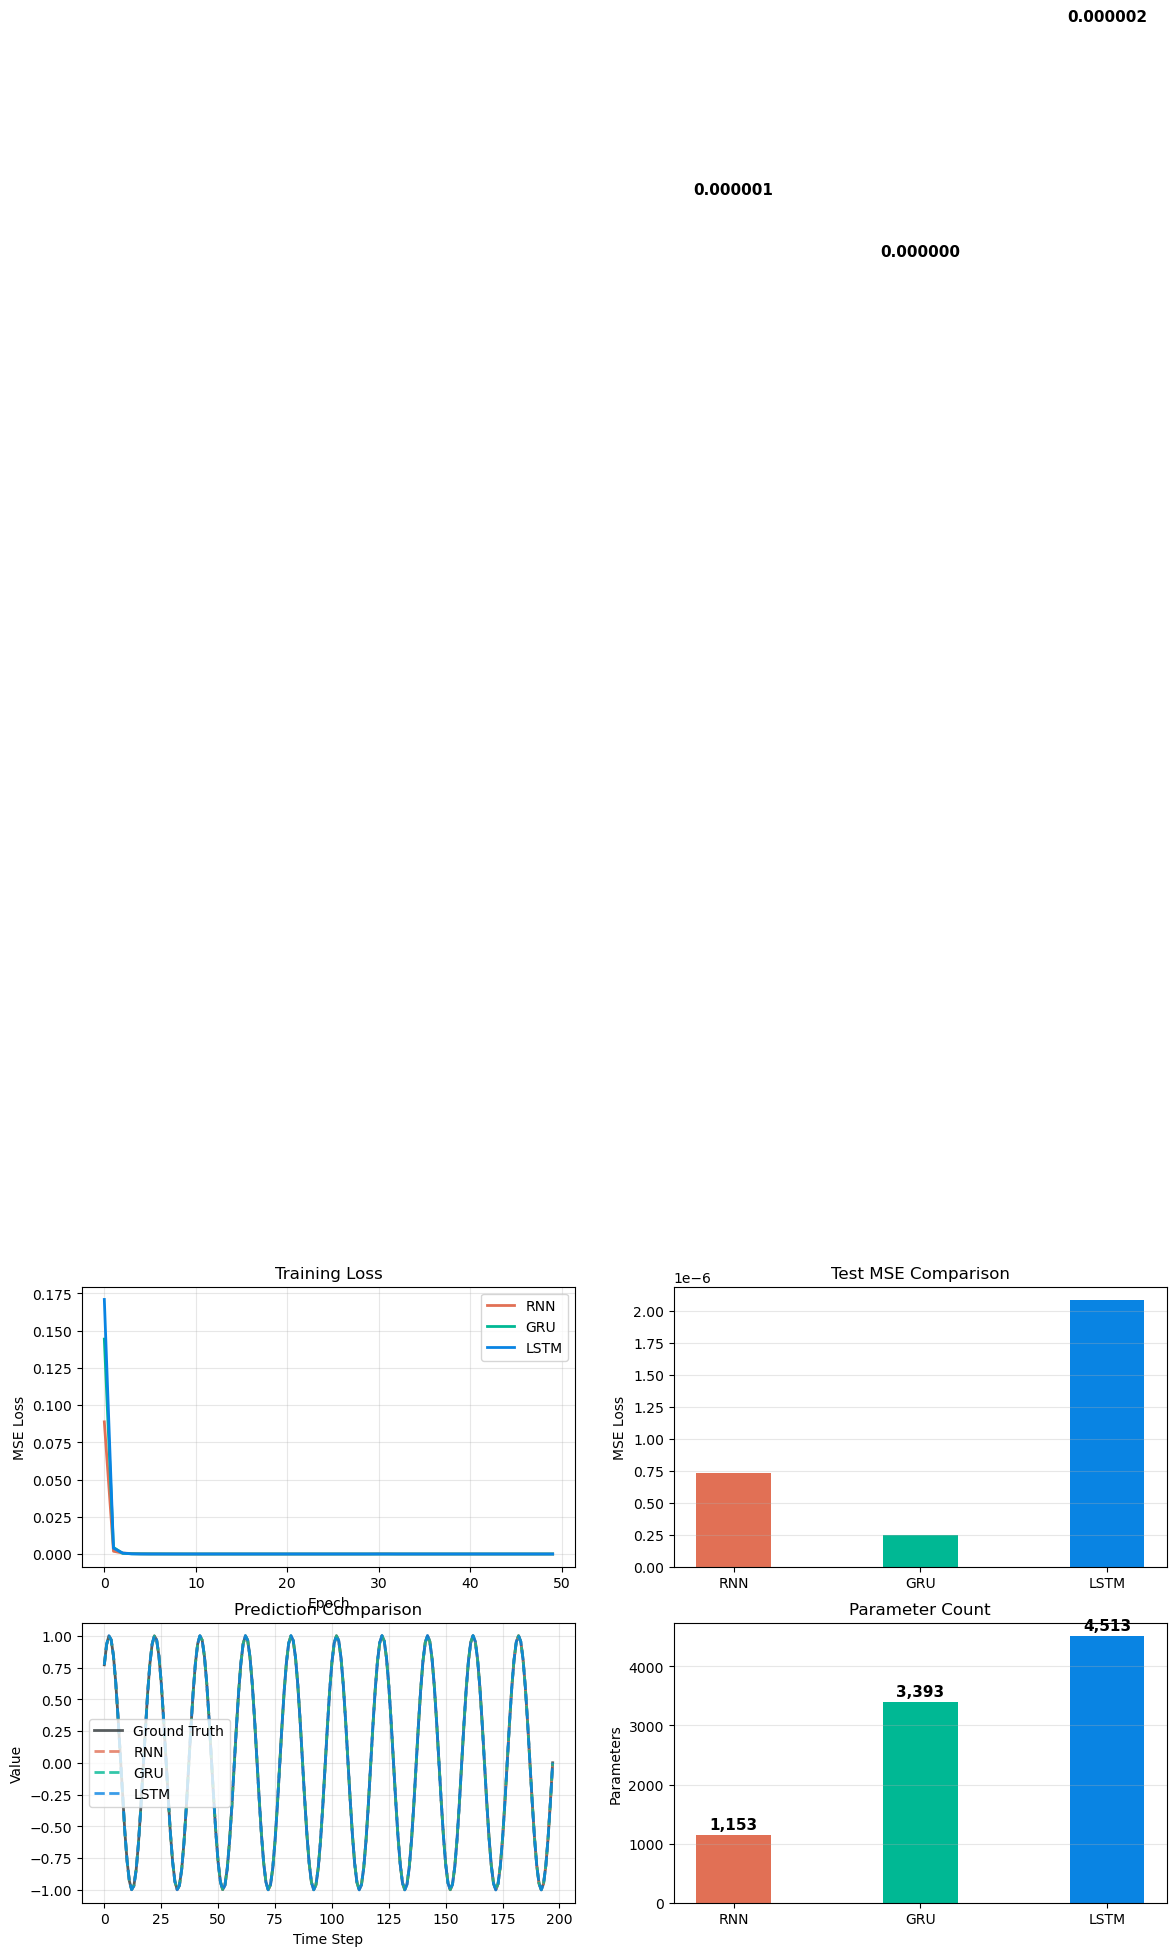

In [8]:
# ============================================
# 三兄弟可视化对比
# ============================================

colors = {'RNN': '#e17055', 'GRU': '#00b894', 'LSTM': '#0984e3'}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 损失曲线
ax = axes[0, 0]
for name, (losses, _) in results.items():
    ax.plot(losses, label=name, lw=2, color=colors[name])
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss'); ax.legend(); ax.grid(alpha=0.3)

# 测试 Loss 柱状图
ax = axes[0, 1]
names = list(results.keys())
test_losses = [results[n][1] for n in names]
bars = ax.bar(names, test_losses, color=[colors[n] for n in names], width=0.4)
ax.set_ylabel('MSE Loss'); ax.set_title('Test MSE Comparison')
ax.grid(alpha=0.3, axis='y')
for bar, v in zip(bars, test_losses):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.00001,
            f'{v:.6f}', ha='center', fontweight='bold', fontsize=11)

# 预测对比
ax = axes[1, 0]
n_show = 200
y_true = y_test.squeeze().numpy()
ax.plot(y_true[:n_show], label='Ground Truth', lw=2, alpha=0.8, color='#2d3436')
for name in names:
    models[name].eval()
    with torch.no_grad():
        y_p = models[name](x_test).squeeze().numpy()
    ax.plot(y_p[:n_show], label=name, lw=2, alpha=0.8, ls='--', color=colors[name])
ax.set_xlabel('Time Step'); ax.set_ylabel('Value')
ax.set_title('Prediction Comparison'); ax.legend(); ax.grid(alpha=0.3)

# 参数量对比
ax = axes[1, 1]
param_counts = [sum(p.numel() for p in models[n].parameters()) for n in names]
bars = ax.bar(names, param_counts, color=[colors[n] for n in names], width=0.4)
ax.set_ylabel('Parameters'); ax.set_title('Parameter Count')
ax.grid(alpha=0.3, axis='y')
for bar, v in zip(bars, param_counts):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100,
            f'{v:,}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('day17_rnn_gru_lstm_comparison.png', dpi=150)
plt.show()

## 4. Seq2Seq - 编码器-解码器架构

> 前几天的 RNN/LSTM/GRU 都是"一个序列 -> 一个序列" (长度相同)
>
> Seq2Seq 解决: "一个序列 -> 另一个不同长度的序列"
>
> 应用: 机器翻译 (英->中), 语音识别, 文本摘要

### 结构

```
编码器 (Encoder)                    解码器 (Decoder)
                                                       
  x1 -> RNN -> h1                   y0  (起始符)        
  x2 -> RNN -> h2                     |                 
  x3 -> RNN -> h3                     v                 
  ...               h_enc --------> RNN -> y1 (预测)    
  xT -> RNN -> hT   (上下文向量)       |                 
                                     v                 
                                   RNN -> y2 (预测)    
                                     |                 
                                    ...               
                                  直到输出 <EOS> 为止   

关键: 编码器的最后一个隐藏状态 = 整个输入序列的"摘要"
      解码器基于这个摘要, 一步步生成输出
```

### Seq2Seq 的局限

```
1. 信息瓶颈: 整个输入序列压缩成一个向量 h_enc, 长序列信息丢失
2. -> Day 18: Attention 机制让解码器可以"回头看"输入序列的每一步
```

In [9]:
# ============================================
# Seq2Seq: 编码器 + 解码器
# ============================================

class Encoder(nn.Module):
    """把输入序列 -> 上下文向量 (最后一个隐藏状态)"""
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, x):
        # x: (batch, seq_len)
        out, hn = self.gru(self.embed(x))  # hn: (1, batch, hidden)
        return hn  # 上下文向量


class Decoder(nn.Module):
    """基于上下文向量, 一步步生成输出序列"""
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, encoder_hn):
        # x: (batch, 1)  <- 上一个时间步的输出
        out, hn = self.gru(self.embed(x), encoder_hn)
        return self.fc(out[:, -1, :]), hn


class Seq2Seq(nn.Module):
    """编码器 + 解码器 = 完整的 Seq2Seq"""
    def __init__(self, encoder, decoder, target_vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.target_vocab_size = target_vocab_size

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        """
        src: (batch, src_len)  输入序列
        trg: (batch, trg_len)  目标序列
        """
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.target_vocab_size

        # 编码
        context = self.encoder(src)  # (1, batch, hidden)

        # 解码: 存储每一步的输出
        outputs = torch.zeros(batch_size, trg_len, vocab_size)

        # 解码器第一个输入: <SOS> (起始符)
        dec_input = trg[:, 0:1]  # (batch, 1)
        dec_hidden = context

        for t in range(1, trg_len):
            dec_output, dec_hidden = self.decoder(dec_input, dec_hidden)
            outputs[:, t, :] = dec_output

            # Teacher Forcing: 用真实值 vs 用预测值
            use_teacher = torch.rand(1).item() < teacher_forcing_ratio
            if use_teacher:
                dec_input = trg[:, t:t+1]  # 下一个输入: 真实值
            else:
                _, top1 = dec_output.topk(1)
                dec_input = top1  # 下一个输入: 模型自己的预测

        return outputs


print('Seq2Seq 结构定义完成')
print('  Encoder: input -> embed -> GRU -> context vector')
print('  Decoder: context vector + prev_token -> GRU -> next_token')
print('  Teacher Forcing: 训练时用真实值引导, 加速收敛')

Seq2Seq 结构定义完成
  Encoder: input -> embed -> GRU -> context vector
  Decoder: context vector + prev_token -> GRU -> next_token
  Teacher Forcing: 训练时用真实值引导, 加速收敛


## 5. Seq2Seq 玩具实战: 字符串反转

> 任务: "hello" -> "olleh" (反转字符串)
>
> 这个任务很简单, 但完美展示了 Seq2Seq 的工作原理

```
编码器输入: h e l l o
解码器输出: o l l e h

解码器起始符 <SOS>: 告诉模型"开始生成"
解码器终止符 <EOS>: 模型学会"输出结束"
```

In [11]:
# ============================================
# 准备反转字符串数据
# ============================================

# 造一些简单的字符串对
pairs = [
    ('hello', 'olleh'),
    ('world', 'dlrow'),
    ('abc',   'cba'),
    ('xyz',   'zyx'),
    ('rnn',   'nnr'),
    ('lstm',  'mtsl'),
    ('gru',   'urg'),
]

# 构建词表
all_chars = set(''.join([s for s, _ in pairs] + [t for _, t in pairs]))
chars = ['<PAD>', '<SOS>', '<EOS>'] + sorted(all_chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)

print(f'词表: {chars}')
print(f'词表大小: {vocab_size}')

def encode_seq(seq, max_len=6):
    """编码序列: 加 <SOS> <EOS> 并补齐"""
    tokens = ['<SOS>'] + list(seq) + ['<EOS>']
    tokens = tokens[:max_len]  # 截断
    tokens = tokens + ['<PAD>'] * (max_len - len(tokens))
    return [stoi[t] for t in tokens]

max_len = 6
src_data = torch.LongTensor([encode_seq(s, max_len) for s, _ in pairs])
trg_data = torch.LongTensor([encode_seq(t, max_len) for _, t in pairs])

print('\n数据示例:')
for i in range(len(pairs)):
    src_str = ''.join(chars[idx] for idx in src_data[i] if chars[idx] not in ['<PAD>'])
    trg_str = ''.join(chars[idx] for idx in trg_data[i] if chars[idx] not in ['<PAD>'])
    print(f'  {src_str} -> {trg_str}')

词表: ['<PAD>', '<SOS>', '<EOS>', 'a', 'b', 'c', 'd', 'e', 'g', 'h', 'l', 'm', 'n', 'o', 'r', 's', 't', 'u', 'w', 'x', 'y', 'z']
词表大小: 22

数据示例:
  <SOS>hello -> <SOS>olleh
  <SOS>world -> <SOS>dlrow
  <SOS>abc<EOS> -> <SOS>cba<EOS>
  <SOS>xyz<EOS> -> <SOS>zyx<EOS>
  <SOS>rnn<EOS> -> <SOS>nnr<EOS>
  <SOS>lstm<EOS> -> <SOS>mtsl<EOS>
  <SOS>gru<EOS> -> <SOS>urg<EOS>


Seq2Seq 总参数量: 3,222
  Epoch  50/300 | Loss = 0.4962
  Epoch 100/300 | Loss = 0.0570
  Epoch 150/300 | Loss = 0.0248
  Epoch 200/300 | Loss = 0.0142
  Epoch 250/300 | Loss = 0.0094
  Epoch 300/300 | Loss = 0.0068


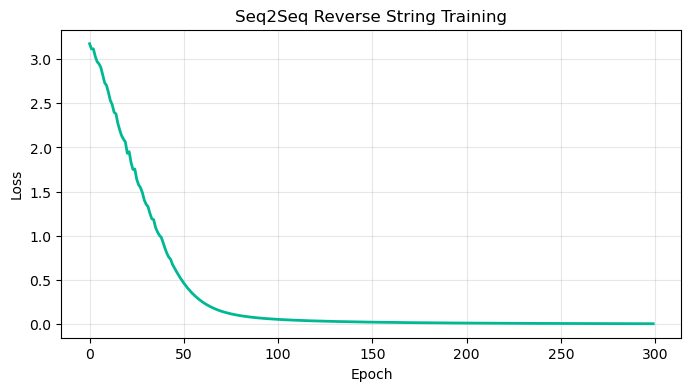

In [12]:
# ============================================
# 训练 Seq2Seq (反转字符串)
# ============================================

enc = Encoder(vocab_size, embed_size=8, hidden_size=16)
dec = Decoder(vocab_size, embed_size=8, hidden_size=16)
model_seq2seq = Seq2Seq(enc, dec, vocab_size)

print(f'Seq2Seq 总参数量: {sum(p.numel() for p in model_seq2seq.parameters()):,}')

criterion = nn.CrossEntropyLoss(ignore_index=stoi['<PAD>'])
optimizer = optim.Adam(model_seq2seq.parameters(), lr=0.01)

n_epochs = 300
losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    output = model_seq2seq(src_data, trg_data, teacher_forcing_ratio=0.5)
    # output: (batch, trg_len, vocab_size)
    # 忽略位置 0 (<SOS>)
    loss = criterion(output[:, 1:, :].reshape(-1, vocab_size),
                     trg_data[:, 1:].reshape(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f'  Epoch {epoch+1:>3d}/{n_epochs} | Loss = {loss.item():.4f}')

plt.figure(figsize=(8, 4))
plt.plot(losses, lw=2, color='#00b894')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Seq2Seq Reverse String Training')
plt.grid(alpha=0.3)
plt.savefig('day17_seq2seq_training.png', dpi=150)
plt.show()

In [14]:
# ============================================
# 测试 Seq2Seq 反转效果
# ============================================

def predict_seq2seq(model, src_str):
    """给定输入字符串, 生成反转结果"""
    model.eval()
    with torch.no_grad():
        # 编码
        src = torch.LongTensor([encode_seq(src_str, max_len)])
        context = model.encoder(src)

        # 解码
        dec_input = torch.LongTensor([[stoi['<SOS>']]])
        dec_hidden = context
        result = []

        for _ in range(max_len):
            dec_output, dec_hidden = model.decoder(dec_input, dec_hidden)
            _, top1 = dec_output.topk(1)
            token = itos[top1.item()]
            if token == '<EOS>':
                break
            if token not in ['<PAD>', '<SOS>']:
                result.append(token)
            dec_input = top1

        return ''.join(result)


test_inputs = ['hello', 'world', 'abc', 'rnn', 'lstm', 'gru']
print('测试结果:')
print(f'{"输入":<10} {"期望":<10} {"预测":<10} {"正确?"}')
print('-' * 40)
for s in test_inputs:
    expected = s[::-1]
    predicted = predict_seq2seq(model_seq2seq, s)
    ok = '✅' if predicted == expected else '❌'
    print(f'{s:<10} {expected:<10} {predicted:<10} {ok}')

# [作业 4] 试试更长的字符串? 比如 'abcd', 'hello!'
#           位置: 上面的 test_inputs 列表, 加新字符串进去
#           观察: 字符串变长后准确率会不会下降 (信息瓶颈)

测试结果:
输入         期望         预测         正确?
----------------------------------------
hello      olleh      ollehh     ❌
world      dlrow      dlrowh     ❌
abc        cba        cba        ✅
rnn        nnr        nnr        ✅
lstm       mtsl       mtsl       ✅
gru        urg        urg        ✅


---

# Day 17 完成!

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **GRU** | 更新门 z (合并遗忘+输入) + 重置门 r (控制过去影响) |
| **GRU vs LSTM** | 3 组权重 vs 4 组, 参数更少, 效果接近 |
| **GRU 加法路径** | h_t = (1-z)*n + z*h_{t-1}, 梯度同样不会消失 |
| **Seq2Seq** | 编码器压缩输入 -> 上下文向量 -> 解码器生成输出 |
| **Teacher Forcing** | 训练时用真实值引导, 让解码器学得更快 |
| **信息瓶颈** | 整个序列压缩成一个向量, 长序列会丢失信息 |

## RNN 演化总结

```
RNN  (1990)   h = tanh(W*[x, h])             1组  梯度消失 ❌
LSTM (1997)   i, f, o, g + C_t               4组  梯度不消失 ✅
GRU  (2014)   z, r (合并遗忘+输入)            3组  梯度不消失 ✅

精度:  LSTM ≈ GRU > RNN
速度:  GRU > LSTM > RNN (GRU计算量在中间)
参数:  LSTM > GRU > RNN
```

## 作业 (代码定位)

### [作业 1] 只训练 GRU
**位置:** cell-9, 第 19-27 行: `for name, model in models.items():` 循环

**问题:** 注释掉 RNN 和 LSTM 的训练 (只留 GRU), 训练速度快了多少?
- 提示: 在 `models` 字典里删掉 'RNN' 和 'LSTM' 即可

---

### [作业 2] 增大 hidden_size
**位置:** cell-8, 第 14-16 行: `RNNPredictor('rnn', 32)` 的 `32`

**问题:** 把 hidden_size 从 32 改成 64, 重新跑 cell-9 和 cell-10, 观察:
- 三种模型的参数量增长了多少?
- 测试 Loss 下降了多少?
- 训练时间增长了多少?

---

### [作业 3] Teacher Forcing 影响
**位置:** cell-12, 第 42 行: `teacher_forcing_ratio=0.5`

**问题:** 改成 0.0 (完全不用) 和 1.0 (完全用), 训练效果有什么变化?
- teacher_forcing_ratio=0: 自己猜下一个词, 可能学得慢
- teacher_forcing_ratio=1: 全是正确答案, 但测试时可能崩
- 修改后重新跑 cell-15 看 loss 曲线

---

### [作业 4] 更长的字符串
**位置:** cell-16, 倒数第 6 行: `test_inputs = [...]`

**问题:** 在列表里加一些更长的字符串 (如 'abcdef', 'hello!'), 观察:
- 当字符串长度超过训练集最大长度时, 反转准确率如何?
- 这说明 Seq2Seq 的信息瓶颈问题有多严重?

---

### [作业 5] 预习
预习 Day 18: Attention (Bahdanau) — 解码器不再只看上下文向量, 可以"回头看"输入序列的每一步